In [1]:
import warnings
warnings.filterwarnings('ignore', category=UserWarning)

import numpy as np
import datetime
import matplotlib.pyplot as plt

# Meteorology data path

In [2]:
hr3lon_full = np.load('/home/disk/hermes/nd349/footprint_unet/HRRR_lon_lat.npz')['lon']
hr3lat_full = np.load('/home/disk/hermes/nd349/footprint_unet/HRRR_lon_lat.npz')['lat']
hr3lon_full = (hr3lon_full+180)%360-180  # convert from 0~360 to -180~180
HRRR_DIR = '/home/disk/hermes2/nd349/data/met_data/xstilt_CONUS_data_lite/'
trimsize = 150

# Domain Information

In [3]:
lats = np.arange(30.384, 33.717, 1/120)
lons = np.arange(-96.323, -92.990, 1/120)
print("Dimension of lats:", lats.shape)
print("Dimension of lons:", lons.shape)
print("Lats spatial resolution:", 1/120)
print("Lons spatial resolution:", 1/120)

Dimension of lats: (400,)
Dimension of lons: (400,)
Lats spatial resolution: 0.008333333333333333
Lons spatial resolution: 0.008333333333333333


# Defining Receptor

In [4]:
timestamp1 = datetime.datetime(2021, 10, 20, 16)
receptor_lon1 = -94.657
receptor_lat1 = 32.618

# Gathering meteorology for a list of receptors

In [5]:
from getSurfaceMeteorology import SurfaceMeteorology

In [6]:
timelist = [timestamp1]
met = SurfaceMeteorology(timelist, lons, lats, trimsize, hr3lat_full, hr3lon_full, HRRR_DIR, backhours=[0, 6, 12, 18, 24])
# met.input_met_dict contains raw meteorology data in a dictionary (key: <timestamp>, value: <meteorology array>)
# met.processed_met_dict contains processed meteorology data in a dictionary (key: <timestamp>, value: <meteorology array>)

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:04<00:00,  4.08s/it]


Plotting Raw Input Meteorology
Timestamp: 2021102016


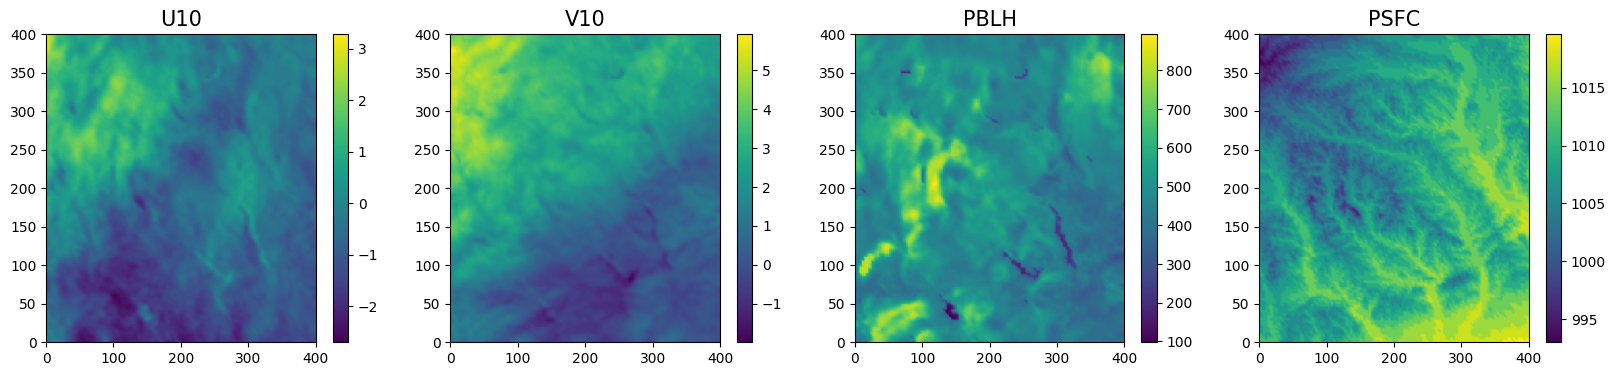

Timestamp: 2021102010


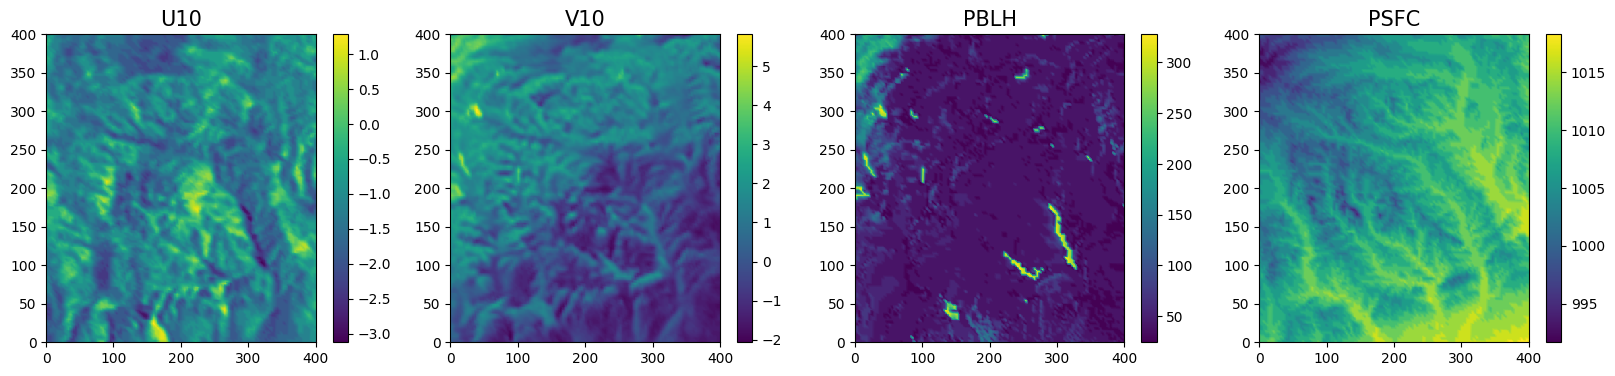

Timestamp: 2021102004


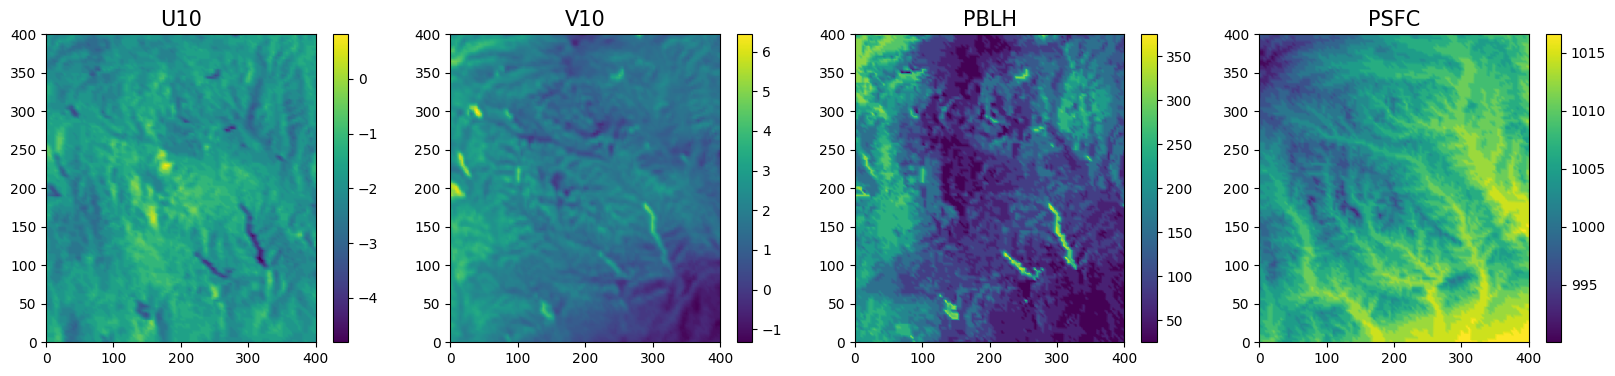

Timestamp: 2021101922


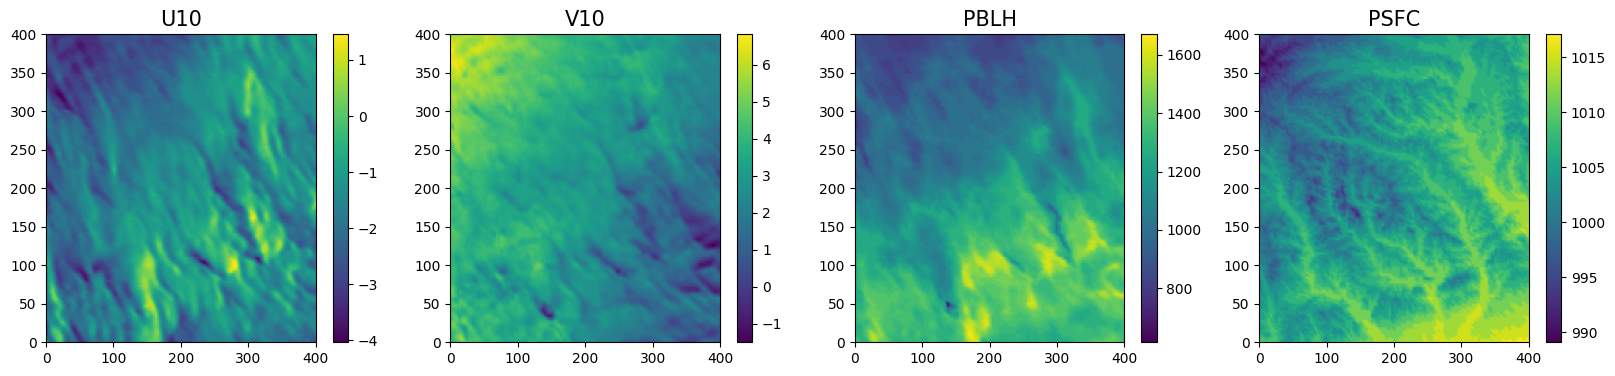

Timestamp: 2021101916


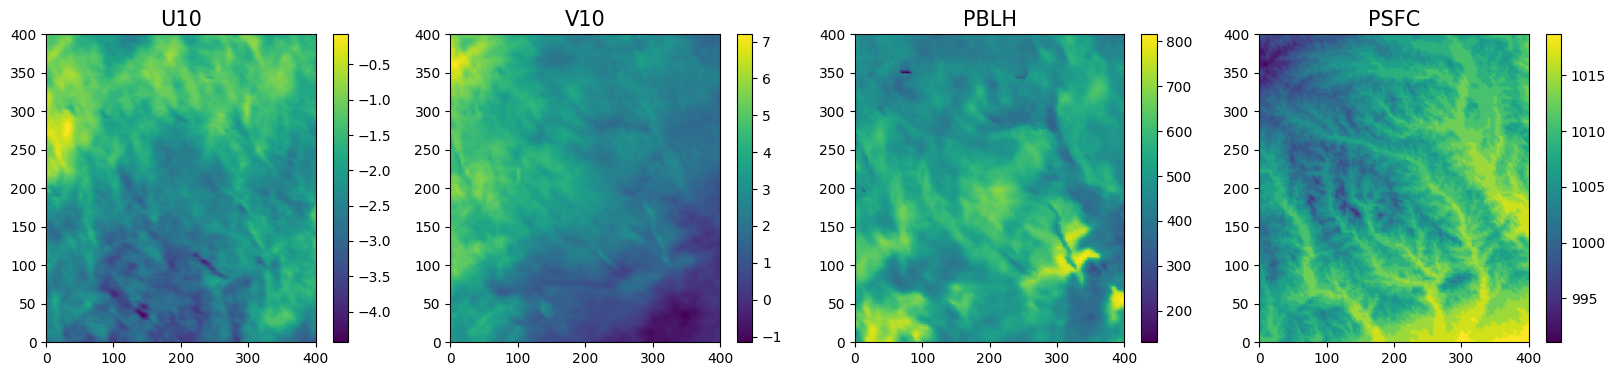

In [7]:
def plot(arr, title=''):
    if len(arr.shape) > 2:
        fig, ax = plt.subplots(1, arr.shape[2], figsize=(20, 4))
        for idx in range(arr.shape[2]):
            h = ax[idx].pcolor(arr[:, :, idx], vmin=np.min(arr[:, :, idx]), vmax=np.max(arr[:, :, idx]))
            fig.colorbar(h, ax=ax[idx])
            if title:
                ax[idx].set_title(title[idx], fontsize=15)
    elif len(a.shape) == 2:
        h = plt.pcolor(arr, vmin=0, vmax=1e-5)
        plt.colorbar(h)
        if title:
            plt.title(title)
    plt.show()

print("Plotting Raw Input Meteorology")
for key in met.input_met_dict:
    print("Timestamp:", key)
    plot(met.input_met_dict[key], title=['U10', 'V10', 'PBLH', 'PSFC'])

# Loading Surface FootNet Model

In [8]:
from SurfaceFootNet import SurfaceFootNet

In [9]:
# Loading FootNet model
model_path = "../models/SurfaceFootNet_in_sample.pth"
model = SurfaceFootNet(model_path=model_path)

Using device: cuda
...Loading ../../models/SurfaceFootNet_in_sample.pth


# Computing footprints for a surface observation

In [10]:
receptors = [[timestamp1, receptor_lon1, receptor_lat1]] # Provide multiple receptors as list of list (order sensitive)
timelist = [timestamp1] # Provide corresponding timestamps as list of list

# Gathering meteorology first
# lons (domain longitudes)
# lats (domain latitudes)
# trimsize (parameter)
print("Loading meteorology")
input_met = SurfaceMeteorology(timelist, lons, lats, trimsize, hr3lat_full, hr3lon_full, HRRR_DIR, backhours=[0, 6, 12, 18, 24])
print("Computing footprints")
foots, reference_indices, reference_timestamps, reference_rlons, reference_rlats = model.run_inference(receptors, input_met)
print(foots.shape, reference_indices, reference_timestamps, reference_rlons, reference_rlats)

Loading meteorology


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:03<00:00,  3.95s/it]

Computing footprints



/home/disk/hermes/nd349/footprint_unet/CONUS/git_repo/FootNet/footnet/SurfaceFootNet.py:109: RuntimeWarning: invalid value encountered in power
  sig     = a*(lx/x0)**0.894


(1, 400, 400) [0] ['2021102016'] [-94.657] [32.618]


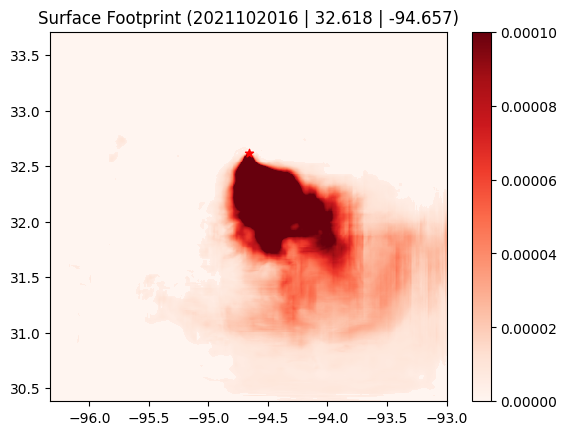

In [11]:
for idx in range(foots.shape[0]):
    temp_foot = foots[idx]
    temp_rlon = reference_rlons[idx]
    temp_rlat = reference_rlats[idx]
    temp_timestamp = reference_timestamps[idx]
    h = plt.pcolor(lons, lats, temp_foot, vmin=0, vmax=1e-4, cmap='Reds')
    plt.colorbar(h)
    plt.title(f"Surface Footprint ({temp_timestamp} | {temp_rlat} | {temp_rlon})")
    plt.scatter([temp_rlon], [temp_rlat], marker='*', color='red')
    plt.show()

# Computing footprints for multiple surface observations

In [12]:
timestamp1 = datetime.datetime(2021, 10, 20, 16)
receptor_lon1 = -94.657
receptor_lat1 = 32.618

timestamp2 = datetime.datetime(2020, 9, 15, 13)
receptor_lon2 = -95.565
receptor_lat2 = 31.804

receptors = [[timestamp1, receptor_lon1, receptor_lat1], [timestamp2, receptor_lon2, receptor_lat2]] # Provide multiple receptors as list of list (order sensitive)
timelist = [timestamp1, timestamp2] # Provide corresponding timestamps as list of list

# Gathering meteorology first
# lons (domain longitudes)
# lats (domain latitudes)
# trimsize (parameter)
print("Loading meteorology")
input_met = SurfaceMeteorology(timelist, lons, lats, trimsize, hr3lat_full, hr3lon_full, HRRR_DIR, backhours=[0, 6, 12, 18, 24])
print("Computing footprints")
foots, reference_indices, reference_timestamps, reference_rlons, reference_rlats = model.run_inference(receptors, input_met)
print(foots.shape, reference_indices, reference_timestamps, reference_rlons, reference_rlats)

Loading meteorology


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2/2 [00:08<00:00,  4.16s/it]

Computing footprints



/home/disk/hermes/nd349/footprint_unet/CONUS/git_repo/FootNet/footnet/SurfaceFootNet.py:109: RuntimeWarning: invalid value encountered in power
  sig     = a*(lx/x0)**0.894


(2, 400, 400) [0 1] ['2021102016', '2020091513'] [-94.657 -95.565] [32.618 31.804]


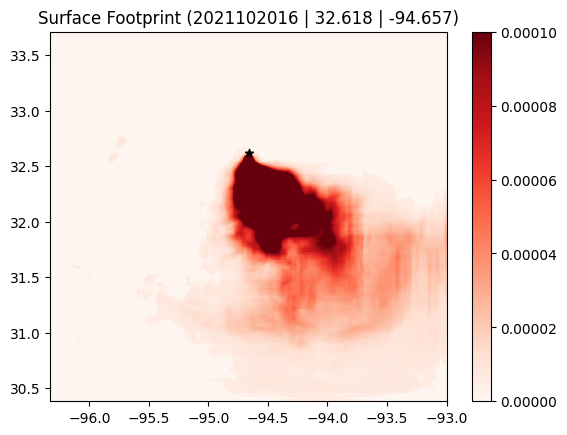

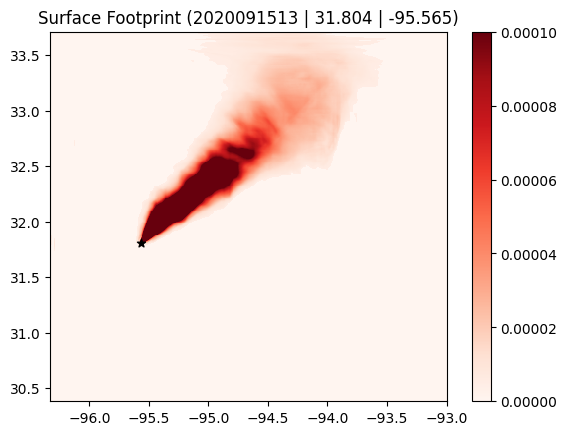

In [13]:
for idx in range(foots.shape[0]):
    temp_foot = foots[idx]
    temp_rlon = reference_rlons[idx]
    temp_rlat = reference_rlats[idx]
    temp_timestamp = reference_timestamps[idx]
    h = plt.pcolor(lons, lats, temp_foot, vmin=0, vmax=1e-4, cmap='Reds')
    plt.colorbar(h)
    plt.title(f"Surface Footprint ({temp_timestamp} | {temp_rlat} | {temp_rlon})")
    plt.scatter([temp_rlon], [temp_rlat], marker='*', color='k')
    plt.show()